In [7]:
import pandas as pd
import numpy as np
df=pd.read_csv("Credit Card.csv")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [9]:
df = df.drop("CUST_ID", axis=1)
df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [10]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Data Dictionary

In [11]:
# Create empty list to store dictionary rows
data_dictionary=[]

for col in df.columns:
    
    total_records=len(df)
    non_null=df[col].notnull().sum()
    fill_rate=round((non_null/total_records)*100,2)
    
    # Determine min and max only for numeric columns
    if pd.api.types.is_numeric_dtype(df[col]):
        minimum=df[col].min()
        maximum=df[col].max()
        var_type="Numerical variable"
    else:
        minimum="-"
        maximum="-"
        var_type="Categorical variable"
    
    distinct_count=df[col].nunique()
    
    # Comments section
    if fill_rate < 100:
        comments=f"Contains missing values,{var_type}"
    else:
        comments=var_type
    
    data_dictionary.append([
        col,
        df[col].dtype,
        total_records,
        fill_rate,
        minimum,
        maximum,
        distinct_count,
        comments
    ])

In [12]:
# Create DataFrame
dictionary_df=pd.DataFrame(data_dictionary, columns=[
    "Variable Name",
    "Type of Variable",
    "Total Records",
    "Fill Rate (%)",
    "Minimum",
    "Maximum",
    "Distinct Count",
    "Comments"
])
dictionary_df

,Variable Name,Type of Variable,Total Records,Fill Rate (%),Minimum,Maximum,Distinct Count,Comments
0,BALANCE,float64,8950,100.00,0.000000,19043.13856,8871,Numerical variable
1,BALANCE_FREQUENCY,float64,8950,100.00,0.000000,1.00000,43,Numerical variable
2,PURCHASES,float64,8950,100.00,0.000000,49039.57000,6203,Numerical variable
3,ONEOFF_PURCHASES,float64,8950,100.00,0.000000,40761.25000,4014,Numerical variable
4,INSTALLMENTS_PURCHASES,float64,8950,100.00,0.000000,22500.00000,4452,Numerical variable
5,CASH_ADVANCE,float64,8950,100.00,0.000000,47137.21176,4323,Numerical variable
6,PURCHASES_FREQUENCY,float64,8950,100.00,0.000000,1.00000,47,Numerical variable
7,ONEOFF_PURCHASES_FREQUENCY,float64,8950,100.00,0.000000,1.00000,47,Numerical variable
8,PURCHASES_INSTALLMENTS_FREQUENCY,float64,8950,100.00,0.000000,1.00000,47,Numerical variable
9,CASH_ADVANCE_FREQUENCY,float64,8950,100.00,0.000000,1.50000,54,Numerical variable


In [13]:
# Save as CSV
dictionary_df.to_csv("CreditCard_Data_Dictionary.csv", index=False)
print("Data Dictionary generated successfully!")


Data Dictionary generated successfully!


# Descriptive Statistics (Univariate Analysis)


In [14]:
import pandas as pd
import numpy as np

In [15]:
import pandas as pd

data = pd.read_csv("Credit Card.csv")
data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [16]:
numeric_data = data.select_dtypes(include=["int64", "float64"])
numeric_data.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [17]:
mean_values = numeric_data.mean()
mean_values

BALANCE                             1564.474828
BALANCE_FREQUENCY                      0.877271
PURCHASES                           1003.204834
ONEOFF_PURCHASES                     592.437371
INSTALLMENTS_PURCHASES               411.067645
CASH_ADVANCE                         978.871112
PURCHASES_FREQUENCY                    0.490351
ONEOFF_PURCHASES_FREQUENCY             0.202458
PURCHASES_INSTALLMENTS_FREQUENCY       0.364437
CASH_ADVANCE_FREQUENCY                 0.135144
CASH_ADVANCE_TRX                       3.248827
PURCHASES_TRX                         14.709832
CREDIT_LIMIT                        4494.449450
PAYMENTS                            1733.143852
MINIMUM_PAYMENTS                     864.206542
PRC_FULL_PAYMENT                       0.153715
TENURE                                11.517318
dtype: float64

In [18]:
median_values = numeric_data.median()
median_values

BALANCE                              873.385231
BALANCE_FREQUENCY                      1.000000
PURCHASES                            361.280000
ONEOFF_PURCHASES                      38.000000
INSTALLMENTS_PURCHASES                89.000000
CASH_ADVANCE                           0.000000
PURCHASES_FREQUENCY                    0.500000
ONEOFF_PURCHASES_FREQUENCY             0.083333
PURCHASES_INSTALLMENTS_FREQUENCY       0.166667
CASH_ADVANCE_FREQUENCY                 0.000000
CASH_ADVANCE_TRX                       0.000000
PURCHASES_TRX                          7.000000
CREDIT_LIMIT                        3000.000000
PAYMENTS                             856.901546
MINIMUM_PAYMENTS                     312.343947
PRC_FULL_PAYMENT                       0.000000
TENURE                                12.000000
dtype: float64

In [19]:
std_dev_values = numeric_data.std()
std_dev_values

BALANCE                             2081.531879
BALANCE_FREQUENCY                      0.236904
PURCHASES                           2136.634782
ONEOFF_PURCHASES                    1659.887917
INSTALLMENTS_PURCHASES               904.338115
CASH_ADVANCE                        2097.163877
PURCHASES_FREQUENCY                    0.401371
ONEOFF_PURCHASES_FREQUENCY             0.298336
PURCHASES_INSTALLMENTS_FREQUENCY       0.397448
CASH_ADVANCE_FREQUENCY                 0.200121
CASH_ADVANCE_TRX                       6.824647
PURCHASES_TRX                         24.857649
CREDIT_LIMIT                        3638.815725
PAYMENTS                            2895.063757
MINIMUM_PAYMENTS                    2372.446607
PRC_FULL_PAYMENT                       0.292499
TENURE                                 1.338331
dtype: float64

In [20]:
min_values = numeric_data.min()
min_values

BALANCE                              0.000000
BALANCE_FREQUENCY                    0.000000
PURCHASES                            0.000000
ONEOFF_PURCHASES                     0.000000
INSTALLMENTS_PURCHASES               0.000000
CASH_ADVANCE                         0.000000
PURCHASES_FREQUENCY                  0.000000
ONEOFF_PURCHASES_FREQUENCY           0.000000
PURCHASES_INSTALLMENTS_FREQUENCY     0.000000
CASH_ADVANCE_FREQUENCY               0.000000
CASH_ADVANCE_TRX                     0.000000
PURCHASES_TRX                        0.000000
CREDIT_LIMIT                        50.000000
PAYMENTS                             0.000000
MINIMUM_PAYMENTS                     0.019163
PRC_FULL_PAYMENT                     0.000000
TENURE                               6.000000
dtype: float64

In [21]:
max_values = numeric_data.max()
max_values

BALANCE                             19043.13856
BALANCE_FREQUENCY                       1.00000
PURCHASES                           49039.57000
ONEOFF_PURCHASES                    40761.25000
INSTALLMENTS_PURCHASES              22500.00000
CASH_ADVANCE                        47137.21176
PURCHASES_FREQUENCY                     1.00000
ONEOFF_PURCHASES_FREQUENCY              1.00000
PURCHASES_INSTALLMENTS_FREQUENCY        1.00000
CASH_ADVANCE_FREQUENCY                  1.50000
CASH_ADVANCE_TRX                      123.00000
PURCHASES_TRX                         358.00000
CREDIT_LIMIT                        30000.00000
PAYMENTS                            50721.48336
MINIMUM_PAYMENTS                    76406.20752
PRC_FULL_PAYMENT                        1.00000
TENURE                                 12.00000
dtype: float64

In [22]:
descriptive_statistics = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Standard Deviation": std_dev_values,
    "Minimum": min_values,
    "Maximum": max_values
})

descriptive_statistics

,Mean,Median,Standard Deviation,Minimum,Maximum
BALANCE,1564.474828,873.385231,2081.531879,0.000000,19043.13856
BALANCE_FREQUENCY,0.877271,1.000000,0.236904,0.000000,1.00000
PURCHASES,1003.204834,361.280000,2136.634782,0.000000,49039.57000
ONEOFF_PURCHASES,592.437371,38.000000,1659.887917,0.000000,40761.25000
INSTALLMENTS_PURCHASES,411.067645,89.000000,904.338115,0.000000,22500.00000
CASH_ADVANCE,978.871112,0.000000,2097.163877,0.000000,47137.21176
PURCHASES_FREQUENCY,0.490351,0.500000,0.401371,0.000000,1.00000
ONEOFF_PURCHASES_FREQUENCY,0.202458,0.083333,0.298336,0.000000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,0.364437,0.166667,0.397448,0.000000,1.00000
CASH_ADVANCE_FREQUENCY,0.135144,0.000000,0.200121,0.000000,1.50000


In [23]:
numeric_data.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


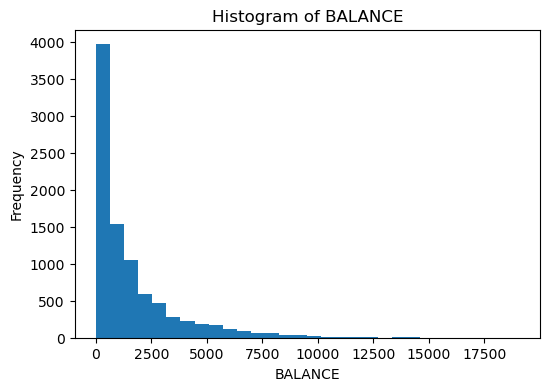

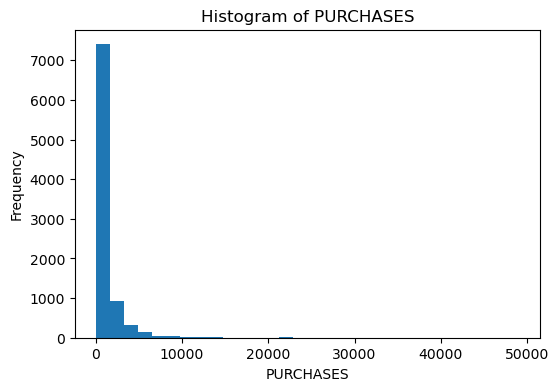

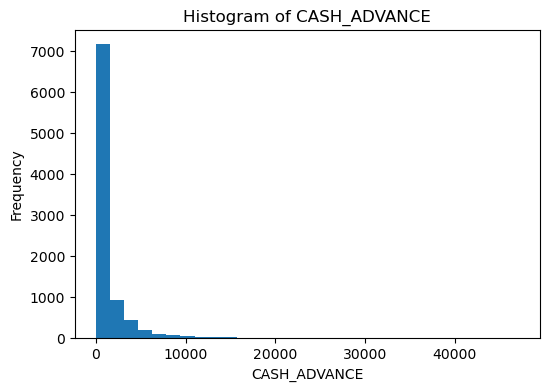

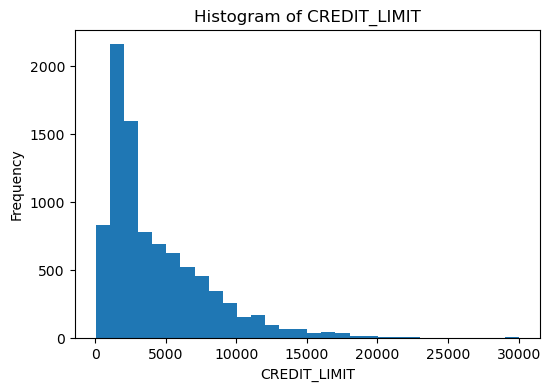

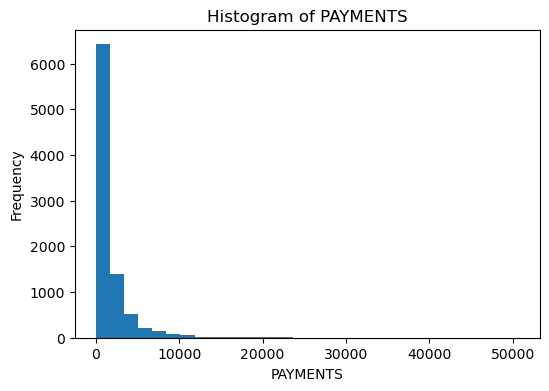

In [24]:
import matplotlib.pyplot as plt

numeric_columns = [
    'BALANCE', 
    'PURCHASES', 
    'CASH_ADVANCE', 
    'CREDIT_LIMIT', 
    'PAYMENTS'
]

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

### Frequency Table

In [25]:
import pandas as pd
import numpy as np
df = pd.read_csv("Credit Card.csv")

In [26]:
#Frequency Table for Balance
grouped = pd.cut(df["BALANCE"], bins=5)
freq = grouped.value_counts().sort_index()
percent = (freq / len(df)) * 100

balance_table = pd.DataFrame({
    "Balance": freq.index.astype(str),
    "Frequency": freq.values,
    "Percentage (%)": percent.values.round(2)
})

balance_table

,Balance,Frequency,Percentage (%)
0,"(-19.043, 3808.628]",7879,88.03
1,"(3808.628, 7617.255]",856,9.56
2,"(7617.255, 11425.883]",175,1.96
3,"(11425.883, 15234.511]",32,0.36
4,"(15234.511, 19043.139]",8,0.09


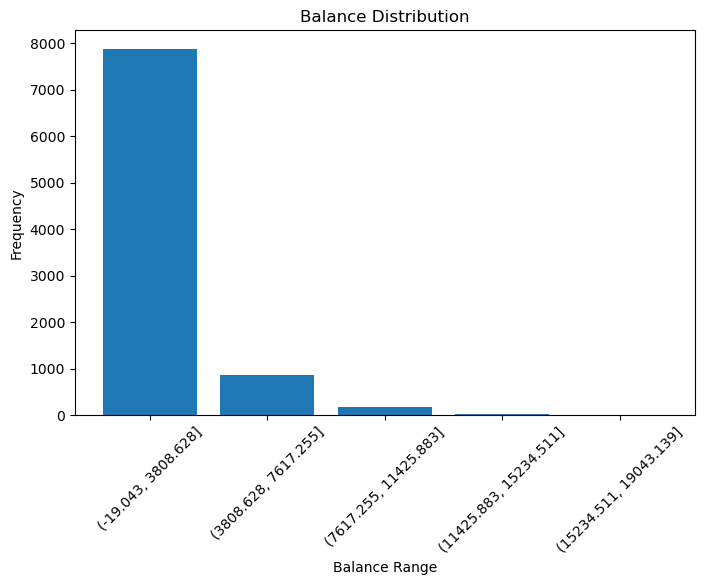

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(balance_table["Balance"], balance_table["Frequency"])

plt.title("Balance Distribution")
plt.xlabel("Balance Range")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

In [28]:
#Most customers maintain low to moderate balance.
#Few customers have very high outstanding balance.

In [29]:
##Frequency Table for Balance Frequency
grouped = pd.cut(df["BALANCE_FREQUENCY"], bins=5)
freq = grouped.value_counts().sort_index()
percent = (freq / len(df)) * 100

balance_freq_table = pd.DataFrame({
    "Balance Frequency": freq.index.astype(str),
    "Frequency": freq.values,
    "Percentage (%)": percent.values.round(2)
})

balance_freq_table

,Balance Frequency,Frequency,Percentage (%)
0,"(-0.001, 0.2]",338,3.78
1,"(0.2, 0.4]",392,4.38
2,"(0.4, 0.6]",478,5.34
3,"(0.6, 0.8]",567,6.34
4,"(0.8, 1.0]",7175,80.17


In [30]:
#The dataset is heavily skewed toward high balance frequency customers.
#Majority are revolvers, not full payers.
#Bank revenue is likely driven mainly by interest from these customers.
#Risk exposure is higher since many customers continuously carry debt.

In [31]:
# Frequenct Table for Purchases
grouped = pd.cut(df["PURCHASES"], bins=5)
freq = grouped.value_counts().sort_index()
percent = (freq / len(df)) * 100

purchases_table = pd.DataFrame({
    "Purchases": freq.index.astype(str),
    "Frequency": freq.values,
    "Percentage (%)": percent.values.round(2)
})

purchases_table

,Purchases,Frequency,Percentage (%)
0,"(-49.04, 9807.914]",8879,99.21
1,"(9807.914, 19615.828]",49,0.55
2,"(19615.828, 29423.742]",15,0.17
3,"(29423.742, 39231.656]",4,0.04
4,"(39231.656, 49039.57]",3,0.03


In [32]:
#Customer base is dominated by low to moderate spenders.
#A small high-spending group drives large transaction values.
#Bank can design:
#Reward programs for high spenders
#Promotions to increase spending of low–mid segment

In [33]:
# Frequency Table for One Off Purchases
grouped = pd.cut(df["ONEOFF_PURCHASES"], bins=5)
freq = grouped.value_counts().sort_index()
percent = (freq / len(df)) * 100

oneoff_table = pd.DataFrame({
    "One-Off Purchases": freq.index.astype(str),
    "Frequency": freq.values,
    "Percentage (%)": percent.values.round(2)
})

oneoff_table

,One-Off Purchases,Frequency,Percentage (%)
0,"(-40.761, 8152.25]",8893,99.36
1,"(8152.25, 16304.5]",40,0.45
2,"(16304.5, 24456.75]",9,0.10
3,"(24456.75, 32609.0]",4,0.04
4,"(32609.0, 40761.25]",4,0.04


In [34]:
#Customer base is dominated by low one-time purchase users.
#High one-off spenders represent a premium and valuable segment.
#Bank can:
#Offer EMI options for big-ticket purchases
#Provide exclusive rewards for large transactions
#Target high-value customers with premium offers

In [35]:
# Frequency Table for Installment Purchases
grouped = pd.cut(df["INSTALLMENTS_PURCHASES"], bins=5)
freq = grouped.value_counts().sort_index()
percent = (freq / len(df)) * 100

installments_table = pd.DataFrame({
    "Installment Purchases": freq.index.astype(str),
    "Frequency": freq.values,
    "Percentage (%)": percent.values.round(2)
})

installments_table

,Installment Purchases,Frequency,Percentage (%)
0,"(-22.5, 4500.0]",8887,99.30
1,"(4500.0, 9000.0]",49,0.55
2,"(9000.0, 13500.0]",11,0.12
3,"(13500.0, 18000.0]",2,0.02
4,"(18000.0, 22500.0]",1,0.01


In [36]:
#Majority customers are not heavy EMI users.
#Installment purchases are concentrated in a small segment.
#Bank can:
#Promote EMI offers to moderate spenders
#Offer low-interest installment schemes
#Target high installment users with loyalty benefits

In [37]:
# Creating bins
bins=[0, 1000, 5000, 10000]

# Creating labels
labels=['0-1000','1000-5000','5000-10000']

# Creating a new column for grouped spending
df['Spending_Range']=pd.cut(df['PURCHASES'], bins=bins, labels=labels, right=False)


In [38]:
# Counting frequency
frequency=df['Spending_Range'].value_counts().sort_index()

# Calculate percentage
percentage=df['Spending_Range'].value_counts(normalize=True).sort_index() * 100

# Combine into one table
frequency_table=pd.DataFrame({
    'Frequency':frequency,
    'Percentage (%)':percentage.round(2)
})

frequency_table

#Interpretation:
#If majority in 0–1000, Most customers are low spenders. The bank should focus on increasing card usage.
#If majority in 1000–5000, Most customers are medium spenders. The bank can target them with loyalty offers.
#If majority in 5000–10000, Most customers are high spenders. The bank should provide premium benefits and rewards.

,Frequency,Percentage (%)
Spending_Range,,
0-1000,6488,73.06
1000-5000,2172,24.46
5000-10000,220,2.48


In [39]:
#Here we are convering range from index into a normal column so that the table looks structured and readable.
frequency_table.reset_index(inplace=True)
frequency_table.columns=['Spending Range','Frequency','Percentage (%)']
frequency_table


,Spending Range,Frequency,Percentage (%)
0,0-1000,6488,73.06
1,1000-5000,2172,24.46
2,5000-10000,220,2.48


In [40]:
#Majority customers show low cash dependency → Lower overall risk.
#Small high-cash segment → High interest income + High default risk.
#Bank should:
#Closely monitor high cash advance users
#Apply strict credit checks
#Offer repayment restructuring if needed

In [41]:
# Frequency table for Cash Advance
cash = pd.cut(df["CASH_ADVANCE"], bins=5)

cash_table = cash.value_counts().sort_index().to_frame("Frequency")
cash_table["Percentage (%)"] = (cash_table["Frequency"] / len(df) * 100).round(2)

cash_table


,Frequency,Percentage (%)
CASH_ADVANCE,,
"(-47.137, 9427.442]",8854,98.93
"(9427.442, 18854.885]",83,0.93
"(18854.885, 28282.327]",11,0.12
"(28282.327, 37709.769]",1,0.01
"(37709.769, 47137.212]",1,0.01


In [42]:
# Frequency table for purchases frequency
grouped = pd.cut(df["PURCHASES_FREQUENCY"], bins=5)
freq = grouped.value_counts().sort_index()
percent = (freq / len(df)) * 100

purchases_freq_table = pd.DataFrame({
    "Purchases Frequency": freq.index.astype(str),
    "Frequency": freq.values,
    "Percentage (%)": percent.values.round(2)
})

purchases_freq_table

,Purchases Frequency,Frequency,Percentage (%)
0,"(-0.001, 0.2]",3293,36.79
1,"(0.2, 0.4]",793,8.86
2,"(0.4, 0.6]",1087,12.15
3,"(0.6, 0.8]",688,7.69
4,"(0.8, 1.0]",3089,34.51


In [43]:
# High frequency users → Loyal and active customers
# Medium frequency users → Growth opportunity
# Low frequency users → Require engagement campaign

In [44]:
# Frequency table for One Off Purchases
oneoff = pd.cut(df["ONEOFF_PURCHASES"], bins=5)

oneoff_table = oneoff.value_counts().sort_index().to_frame("Frequency")
oneoff_table["Percentage (%)"] = (oneoff_table["Frequency"] / len(df) * 100).round(2)

oneoff_table

,Frequency,Percentage (%)
ONEOFF_PURCHASES,,
"(-40.761, 8152.25]",8893,99.36
"(8152.25, 16304.5]",40,0.45
"(16304.5, 24456.75]",9,0.10
"(24456.75, 32609.0]",4,0.04
"(32609.0, 40761.25]",4,0.04


In [45]:
#Majority are low one-time spenders.
#Small high-value segment drives major transaction volume.
#Bank can:
#Offer EMI options for large purchases
#Provide cashback or bonus rewards on big-ticket transactions
#Target premium customers with exclusive benefits

In [46]:
# Frequency table for Purchases Installments Frequency
grouped = pd.cut(df["PURCHASES_INSTALLMENTS_FREQUENCY"], bins=5)
freq = grouped.value_counts().sort_index()
percent = (freq / len(df)) * 100

install_freq_table = pd.DataFrame({
    "Purchases Installment Frequency": freq.index.astype(str),
    "Frequency": freq.values,
    "Percentage (%)": percent.values.round(2)
})

install_freq_table

,Purchases Installment Frequency,Frequency,Percentage (%)
0,"(-0.001, 0.2]",4556,50.91
1,"(0.2, 0.4]",572,6.39
2,"(0.4, 0.6]",1002,11.20
3,"(0.6, 0.8]",682,7.62
4,"(0.8, 1.0]",2138,23.89


In [47]:
#Installment usage is concentrated in a smaller segment.
#High-frequency EMI users contribute steady revenue.
#Bank can:
#Offer low-interest EMI schemes
#Provide special EMI discounts during festivals
#Target moderate users with promotional installment offers

In [48]:
# Frequenct table for Credit Limit
credit = pd.cut(df["CREDIT_LIMIT"], bins=5)

credit_table = credit.value_counts().sort_index().to_frame("Frequency")
credit_table["Percentage (%)"] = (credit_table["Frequency"] / len(df) * 100).round(2)
credit_table

,Frequency,Percentage (%)
CREDIT_LIMIT,,
"(20.05, 6040.0]",6678,74.61
"(6040.0, 12030.0]",1904,21.27
"(12030.0, 18020.0]",324,3.62
"(18020.0, 24010.0]",39,0.44
"(24010.0, 30000.0]",4,0.04


In [49]:
#Majority customers are in moderate credit limit category → Stable portfolio.
#Small high-limit segment → High revenue potential but higher risk.
#Bank can:
#Offer credit limit upgrades to reliable medium customers
#Provide premium services to high-limit customers
#Monitor high-limit accounts for risk management

In [50]:
#Frequency table for Payments
payments = pd.cut(df["PAYMENTS"], bins=5)

payments_table = payments.value_counts().sort_index().to_frame("Frequency")
payments_table["Percentage (%)"] = (payments_table["Frequency"] / len(df) * 100).round(2)
payments_table

,Frequency,Percentage (%)
PAYMENTS,,
"(-50.721, 10144.297]",8786,98.17
"(10144.297, 20288.593]",122,1.36
"(20288.593, 30432.89]",30,0.34
"(30432.89, 40577.187]",9,0.10
"(40577.187, 50721.483]",3,0.03


In [51]:
#Majority making lower payments → Possible interest revenue generation.
#Medium payers → Stable and low-risk customers.
#High payers → Strong repayment capacity and premium segment.
#Bank can:
#Encourage full payment behavior to reduce risk
#Offer loyalty benefits to high repayment customers
#Monitor low payment customers for potential default risk

In [52]:
#Frequency table for Tenure
tenure_table = df["TENURE"].value_counts().sort_index().to_frame("Frequency")
tenure_table["Percentage (%)"] = (tenure_table["Frequency"] / len(df) * 100).round(2)
tenure_table

,Frequency,Percentage (%)
TENURE,,
6,204,2.28
7,190,2.12
8,196,2.19
9,175,1.96
10,236,2.64
11,365,4.08
12,7584,84.74


In [53]:
#Most customers completed a full-year cycle.
#Dataset is highly concentrated in 12-month accounts.
#Tenure variable has low variation.

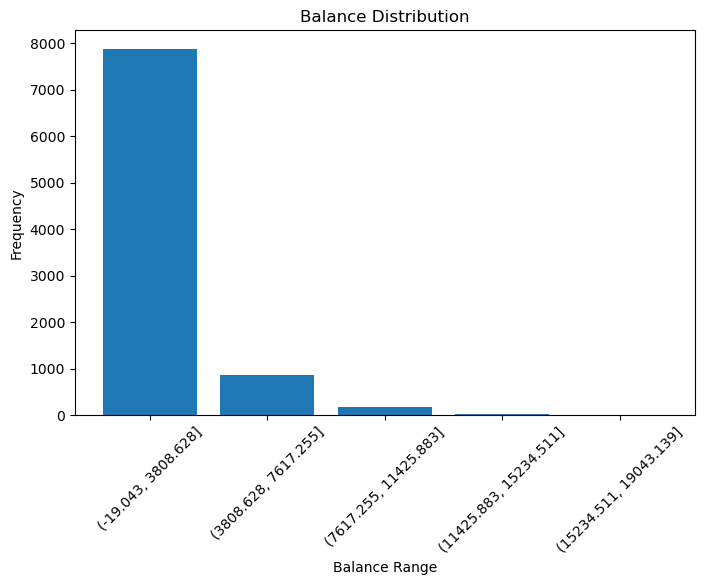

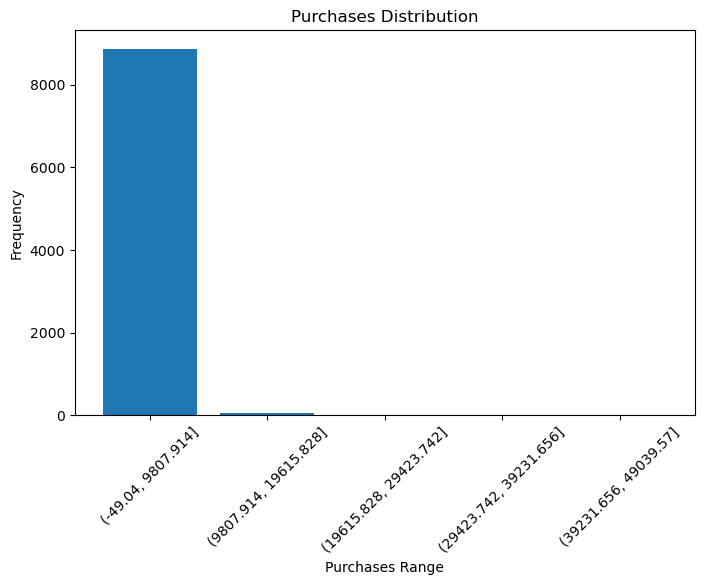

KeyError: 'Credit Limit'

<Figure size 800x500 with 0 Axes>

In [54]:
#graphs for frequency tables
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(balance_table["Balance"], balance_table["Frequency"])

plt.title("Balance Distribution")
plt.xlabel("Balance Range")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(8,5))
plt.bar(purchases_table["Purchases"], purchases_table["Frequency"])

plt.title("Purchases Distribution")
plt.xlabel("Purchases Range")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(8,5))
plt.bar(credit_table["Credit Limit"], credit_table["Frequency"])

plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit Range")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()



# Bivariate Analysis

In [ ]:
bivariate_table = df.groupby('Spending_Range')['CREDIT_LIMIT'].mean().reset_index()
bivariate_table

In [ ]:
bivariate_table.plot(x='Spending_Range', y='CREDIT_LIMIT', kind='bar')
plt.title('Average Credit Limit by Spending Range')
plt.ylabel('Average Credit Limit')
plt.show()

In [ ]:
bivariate_table = df.groupby('Spending_Range')['BALANCE'].mean().reset_index()
bivariate_table

In [ ]:
bivariate_table.plot(x='Spending_Range', y='BALANCE', kind='bar')

In [ ]:
bivariate_table = df.groupby('Spending_Range')['CASH_ADVANCE'].mean().reset_index()
bivariate_table

In [ ]:
bivariate_table.plot(x='Spending_Range', y='CASH_ADVANCE', kind='bar')

In [ ]:
bivariate_table = df.groupby('Spending_Range')['PAYMENTS'].mean().reset_index()
bivariate_table

In [ ]:
bivariate_table.plot(x='Spending_Range', y='PAYMENTS', kind='bar')

In [ ]:
bivariate_table = df.groupby('Spending_Range')['TENURE'].mean().reset_index()
bivariate_table

In [55]:
bivariate_table.plot(x='Spending_Range', y='TENURE', kind='bar')

NameError: name 'bivariate_table' is not defined

# Decile Analysis

In [56]:
df["Spending_Decile"] = pd.qcut(
    df["PURCHASES"], 
    10, 
    labels=False, 
    duplicates="drop"
)
print(df["Spending_Decile"])

0       1
1       0
2       4
3       6
4       0
       ..
8945    2
8946    2
8947    1
8948    0
8949    5
Name: Spending_Decile, Length: 8950, dtype: int64


In [57]:
df["Spending_Decile"].value_counts().sort_index()

Spending_Decile
0    2685
1     895
2     895
3     895
4     895
5     895
6     895
7     895
Name: count, dtype: int64

In [58]:
#Due to a high concentration of zero and low purchase values,
#duplicate quantile boundaries were removed during decile creation,resulting in fewer than ten distinct groups.

In [59]:
decile_table = df.groupby("Spending_Decile")["PURCHASES"].agg(["count", "min", "max", "mean", "sum"]).reset_index()
decile_table

,Spending_Decile,count,min,max,mean,sum
0,0,2685,0.00,89.04,12.356019,33175.91
1,1,895,89.39,212.82,148.194056,132633.68
2,2,895,212.87,361.07,284.867363,254956.29
3,3,895,361.49,557.19,456.728369,408771.89
4,4,895,558.08,894.28,711.196916,636521.24
5,5,895,894.40,1422.12,1126.457620,1008179.57
6,6,895,1423.71,2542.61,1900.287564,1700757.37
7,7,895,2542.75,49039.57,5367.248391,4803687.31


In [60]:
total_spending = df["PURCHASES"].sum()
decile_table["Spending_%"]=(decile_table["sum"]/total_spending)*100
decile_table

,Spending_Decile,count,min,max,mean,sum,Spending_%
0,0,2685,0.00,89.04,12.356019,33175.91,0.369496
1,1,895,89.39,212.82,148.194056,132633.68,1.477206
2,2,895,212.87,361.07,284.867363,254956.29,2.839573
3,3,895,361.49,557.19,456.728369,408771.89,4.552693
4,4,895,558.08,894.28,711.196916,636521.24,7.089249
5,5,895,894.40,1422.12,1126.457620,1008179.57,11.228590
6,6,895,1423.71,2542.61,1900.287564,1700757.37,18.942169
7,7,895,2542.75,49039.57,5367.248391,4803687.31,53.501022


In [61]:
#Top group (Decile 7):
#53.50% of total spending.
#10% of customers generate more than half the revenue.

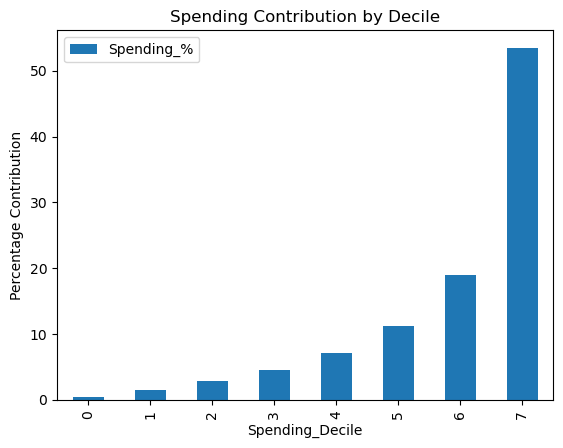

In [62]:
import matplotlib.pyplot as plt

decile_table.plot(x="Spending_Decile", y="Spending_%", kind="bar")
plt.title("Spending Contribution by Decile")
plt.ylabel("Percentage Contribution")
plt.show()

In [63]:
#The decile analysis shows that spending is highly concentrated among a small group of customers.
#The highest spending group (Decile 7) contributes about 53.5% of total purchases
#while the lowest group contributes less than 1%.
#This indicates that a small percentage of customers generate the majority of revenue,
#making them very important for the business.

In [64]:
print("Frequency Table for CUST_ID")
print(df["CUST_ID"].value_counts(dropna=False))

Frequency Table for CUST_ID
CUST_ID
C10001    1
C16135    1
C16129    1
C16130    1
C16131    1
         ..
C13065    1
C13064    1
C13063    1
C13062    1
C19190    1
Name: count, Length: 8950, dtype: int64


In [65]:
balance_freq = pd.cut(df["BALANCE"], bins=5).value_counts().sort_index()
print(balance_freq)

BALANCE
(-19.043, 3808.628]       7879
(3808.628, 7617.255]       856
(7617.255, 11425.883]      175
(11425.883, 15234.511]      32
(15234.511, 19043.139]       8
Name: count, dtype: int64


In [66]:
balance_decile_table = df.groupby("Spending_Decile")["BALANCE"].agg(["count", "min", "max", "mean", "sum"]).reset_index()
balance_decile_table

,Spending_Decile,count,min,max,mean,sum
0,0,2685,0.000000,14581.45914,1870.946252,5.023491e+06
1,1,895,0.000000,12478.17286,1014.222558,9.077292e+05
2,2,895,0.000000,13968.47957,1108.406424,9.920237e+05
3,3,895,0.000000,15258.22590,1109.149953,9.926892e+05
4,4,895,0.000000,16115.59640,1194.279226,1.068880e+06
5,5,895,0.000000,15532.33972,1408.400523,1.260518e+06
6,6,895,1.632453,16304.88925,1663.910456,1.489200e+06
7,7,895,0.000000,19043.13856,2533.540379,2.267519e+06


In [67]:
total_balance = df["BALANCE"].sum()
balance_decile_table["Balance_%"] = (balance_decile_table["sum"] / total_balance) * 100
balance_decile_table

,Spending_Decile,count,min,max,mean,sum,Balance_%
0,0,2685,0.000000,14581.45914,1870.946252,5.023491e+06,35.876824
1,1,895,0.000000,12478.17286,1014.222558,9.077292e+05,6.482831
2,2,895,0.000000,13968.47957,1108.406424,9.920237e+05,7.084847
3,3,895,0.000000,15258.22590,1109.149953,9.926892e+05,7.089599
4,4,895,0.000000,16115.59640,1194.279226,1.068880e+06,7.633739
5,5,895,0.000000,15532.33972,1408.400523,1.260518e+06,9.002385
6,6,895,1.632453,16304.88925,1663.910456,1.489200e+06,10.635585
7,7,895,0.000000,19043.13856,2533.540379,2.267519e+06,16.194191


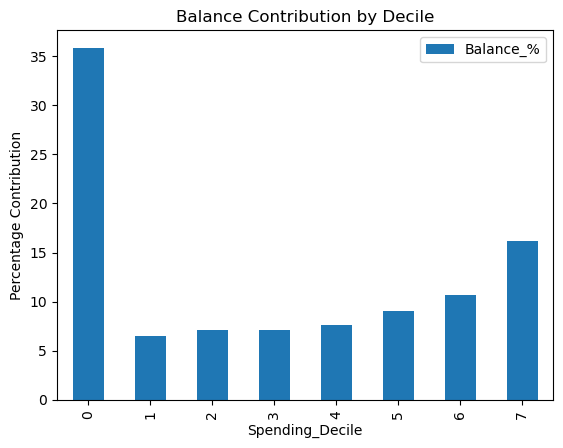

In [68]:
import matplotlib.pyplot as plt

balance_decile_table.plot(x="Spending_Decile", y="Balance_%", kind="bar")
plt.title("Balance Contribution by Decile")
plt.ylabel("Percentage Contribution")
plt.show()

In [69]:
credit_decile_table = df.groupby("Spending_Decile")["CREDIT_LIMIT"].agg(["count", "min", "max", "mean", "sum"]).reset_index()
credit_decile_table

,Spending_Decile,count,min,max,mean,sum
0,0,2684,50.0,19000.0,3881.051122,1.041674e+07
1,1,895,300.0,19500.0,3439.273743,3.078150e+06
2,2,895,150.0,18500.0,3667.486034,3.282400e+06
3,3,895,450.0,23000.0,3824.511596,3.422938e+06
4,4,895,300.0,20000.0,4138.168839,3.703661e+06
5,5,895,300.0,20000.0,4860.863439,4.350473e+06
6,6,895,300.0,25000.0,5565.826985,4.981415e+06
7,7,895,450.0,30000.0,7804.525140,6.985050e+06


In [70]:
total_credit = df["CREDIT_LIMIT"].sum()
credit_decile_table["CreditLimit_%"] = (credit_decile_table["sum"] / total_credit) * 100
credit_decile_table

,Spending_Decile,count,min,max,mean,sum,CreditLimit_%
0,0,2684,50.0,19000.0,3881.051122,1.041674e+07,25.898873
1,1,895,300.0,19500.0,3439.273743,3.078150e+06,7.653124
2,2,895,150.0,18500.0,3667.486034,3.282400e+06,8.160946
3,3,895,450.0,23000.0,3824.511596,3.422938e+06,8.510362
4,4,895,300.0,20000.0,4138.168839,3.703661e+06,9.208316
5,5,895,300.0,20000.0,4860.863439,4.350473e+06,10.816467
6,6,895,300.0,25000.0,5565.826985,4.981415e+06,12.385163
7,7,895,450.0,30000.0,7804.525140,6.985050e+06,17.366748


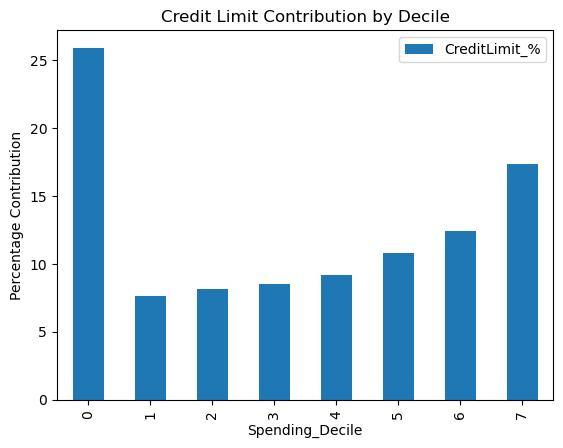

In [71]:
credit_decile_table.plot(x="Spending_Decile", y="CreditLimit_%", kind="bar")
plt.title("Credit Limit Contribution by Decile")
plt.ylabel("Percentage Contribution")
plt.show()

In [72]:
#Creating Spending Decile column
df["Spending_Decile"] = pd.qcut(df["PURCHASES"],10,labels=False,duplicates="drop")

In [73]:
#decile table for payment
payments_decile_table = df.groupby("Spending_Decile")["PAYMENTS"].agg(["count", "min", "max", "mean", "sum"]).reset_index()
payments_decile_table

,Spending_Decile,count,min,max,mean,sum
0,0,2685,0.0,34107.07499,1465.663029,3.935305e+06
1,1,895,0.0,28988.97388,771.485680,6.904797e+05
2,2,895,0.0,12124.63957,966.992981,8.654587e+05
3,3,895,0.0,39048.59762,1021.095011,9.138800e+05
4,4,895,0.0,14040.86635,1181.328293,1.057289e+06
5,5,895,0.0,20873.22194,1636.749657,1.464891e+06
6,6,895,0.0,40627.59524,2207.710238,1.975901e+06
7,7,895,0.0,50721.48336,5149.087575,4.608433e+06


In [74]:
#Percentage Contribution of PAYMENTS
total_payments = df["PAYMENTS"].sum()
payments_decile_table["Payments_%"] = (payments_decile_table["sum"] / total_payments) * 100
payments_decile_table

,Spending_Decile,count,min,max,mean,sum,Payments_%
0,0,2685,0.0,34107.07499,1465.663029,3.935305e+06,25.370018
1,1,895,0.0,28988.97388,771.485680,6.904797e+05,4.451366
2,2,895,0.0,12124.63957,966.992981,8.654587e+05,5.579416
3,3,895,0.0,39048.59762,1021.095011,9.138800e+05,5.891577
4,4,895,0.0,14040.86635,1181.328293,1.057289e+06,6.816101
5,5,895,0.0,20873.22194,1636.749657,1.464891e+06,9.443819
6,6,895,0.0,40627.59524,2207.710238,1.975901e+06,12.738182
7,7,895,0.0,50721.48336,5149.087575,4.608433e+06,29.709522


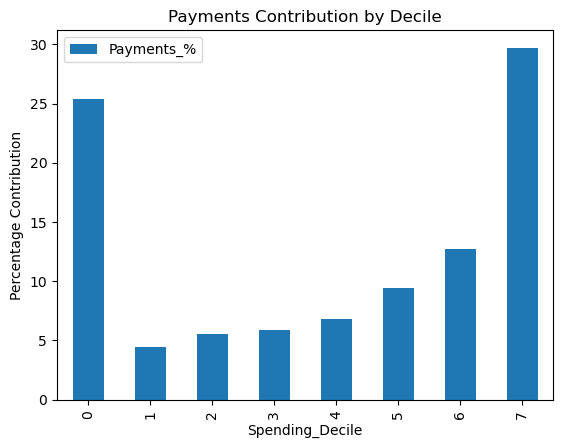

In [75]:
import matplotlib.pyplot as plt

payments_decile_table.plot(x="Spending_Decile", y="Payments_%", kind="bar")
plt.title("Payments Contribution by Decile")
plt.ylabel("Percentage Contribution")
plt.show()

In [76]:
#As the decile increases, the amount of payments made by customers also increases. 
#Customers in the higher deciles make higher payments compared to those in the lower deciles.

In [77]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [78]:
# Drop CUST_ID column
df = df.drop("CUST_ID", axis=1)
df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Spending_Range,Spending_Decile
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0-1000,1
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0-1000,0
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0-1000,4
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12,1000-5000,6
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0-1000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6,0-1000,2
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6,0-1000,2
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6,0-1000,1
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6,0-1000,0


In [79]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Credit Card.csv")
df



# Keep only numeric columns
df = df.select_dtypes(include='number')
df

# Standardize
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print(df_scaled)

[[-0.73198937 -0.24943448 -0.42489974 ... -0.30548157 -0.52555097
   0.36067954]
 [ 0.78696085  0.13432467 -0.46955188 ...  0.08773463  0.2342269
   0.36067954]
 [ 0.44713513  0.51808382 -0.10766823 ... -0.09986968 -0.52555097
   0.36067954]
 ...
 [-0.7403981  -0.18547673 -0.40196519 ... -0.32954733  0.32919999
  -4.12276757]
 [-0.74517423 -0.18547673 -0.46955188 ... -0.34078648  0.32919999
  -4.12276757]
 [-0.57257511 -0.88903307  0.04214581 ... -0.3270727  -0.52555097
  -4.12276757]]


In [80]:
#handle missing alues with mean 
# Handle missing values
df = df.fillna(df.select_dtypes(include='number').mean())
df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,864.206542,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [81]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [82]:
# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.31096755,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.08931021,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.10166318,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.33546549,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.34690648,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.33294642,
        -0.52555097, -4.12276757]], shape=(8950, 17))

In [83]:
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [84]:
# Fit and predict clusters
clusters = kmeans.fit_predict(df_scaled)
clusters

array([1, 0, 2, ..., 1, 1, 1], shape=(8950,), dtype=int32)

In [85]:
# Add cluster labels
df['Cluster'] = clusters

In [86]:
# Count customers
print(df['Cluster'].value_counts())

# Profiling
print(df.groupby('Cluster').mean())

Cluster
1    4559
2    3150
0    1241
Name: count, dtype: int64
             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        4545.974404           0.968555   578.629243        363.840483   
1         943.444730           0.789577   302.146789        207.553551   
2        1288.676491           0.968227  2185.116559       1239.540251   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    214.870685   4513.943197             0.286012   
1                     94.891652    530.425643             0.244520   
2                    945.965035    235.200775             0.926645   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                          0.136806                          0.18702

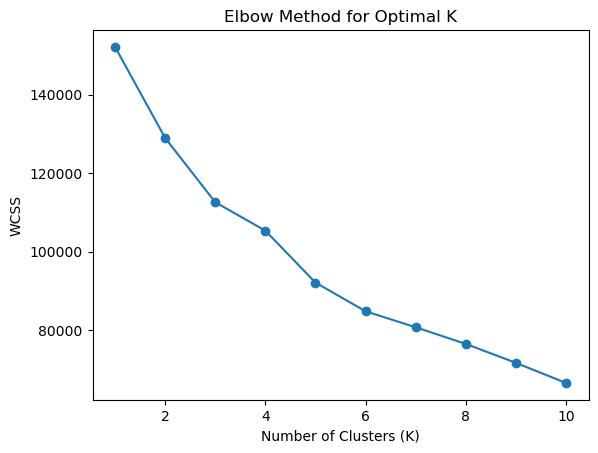

In [87]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the scree (elbow) plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [88]:
# Display result
print(df.head())

       BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0    40.900749           0.818182      95.40              0.00   
1  3202.467416           0.909091       0.00              0.00   
2  2495.148862           1.000000     773.17            773.17   
3  1666.670542           0.636364    1499.00           1499.00   
4   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000                          0.000000   
2                

In [89]:
#Cluster 0 → Customers with low balance and low purchases
#Cluster 1 → Customers with moderate spending
#Cluster 2 → Customers with high balance and high purchases

In [90]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

In [91]:
print(df.isnull().sum())

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
Cluster                             0
dtype: int64


In [92]:
print(df.describe())

            BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
count   8950.000000        8950.000000   8950.000000       8950.000000   
mean    1564.474828           0.877271   1003.204834        592.437371   
std     2081.531879           0.236904   2136.634782       1659.887917   
min        0.000000           0.000000      0.000000          0.000000   
25%      128.281915           0.888889     39.635000          0.000000   
50%      873.385231           1.000000    361.280000         38.000000   
75%     2054.140036           1.000000   1110.130000        577.405000   
max    19043.138560           1.000000  49039.570000      40761.250000   

       INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
count             8950.000000   8950.000000          8950.000000   
mean               411.067645    978.871112             0.490351   
std                904.338115   2097.163877             0.401371   
min                  0.000000      0.000000             0.000